# Llama-3-8B-Instruct - Layer-wise Probe Ablation

**Research question:** *Which transformer depths carry the hallucination
signal, and is the 3-layer concatenation used by the closed-loop system
actually worth its extra parameters?*

This notebook is a **focused, self-contained ablation**. It keeps only the
machinery needed to train the CEV/IAV hallucination probes and strips out the
full closed-loop pipeline (FAISS retrieval, policy network / REINFORCE,
multi-turn tracking, HaluEval scoring, demos, checkpointing). The expensive
language-model forward pass is executed **once per sample (batched on the GPU)**,
and every layer configuration reuses the cached activations.

### What is this, from the basics?
- **Layer** - one decoder block. Llama-3-8B-Instruct is a stack of **32 blocks**; text is
  refined block by block, each holding an internal representation of meaning so far.
- **Probe** - a *tiny* classifier attached to the **frozen** model. We never change the
  backbone; we just read its internal numbers and ask whether a small MLP can predict
  *"is this answer a hallucination?"* from them.
- **Ablation** - vary one ingredient (here: **which layers feed the probe**) and measure
  the effect.

### The two signals per layer
- **CEV** = decoder-block output (residual stream), width = `hidden_size` = **4096**.
- **IAV** = MLP input to `down_proj` (post-activation), width = `intermediate_size` = **14336**.

Two probes (CEV, IAV) are trained and **fused** (val-tuned weighted average); each
per-layer vector is **pooled to the last token**.

### Depths probed: N/4, N/2, 3N/4
| Name | Formula | 32-layer index | Intuition |
|------|---------|:----------------------:|-----------|
| **early** | `N/4`  | **8**  | surface / retrieval-overlap cues |
| **mid**   | `N/2`  | **16** | semantic consistency of answer vs context |
| **late**  | `3N/4` | **24** | "answer commitment" - near-final decision |

### What we compare: Single vs Double vs Triple
The only difference is **how many per-layer vectors are concatenated** into the probe
input - same model, same forward pass, same cached vectors.

| Depth | Configurations | Count | CEV input | IAV input | ~ probe params |
|-------|----------------|:-----:|:---------:|:---------:|:--------------:|
| **Single (1 layer)** | `{8}`, `{16}`, `{24}` | 3 | 4096 | 14336 | **~4.79M** |
| **Double (2 layers)** | `{8,16}`, `{8,24}`, `{16,24}` | 3 | 8192 | 28672 | **~9.51M** |
| **Triple (3 layers)** | `{8,16,24}` - *deployed system* | 1 | 12288 | 43008 | **~14.22M** |

Counts are "ways to choose layers from {8, 16, 24}": 1-of-3 -> 3, 2-of-3 -> 3,
3-of-3 -> 1, i.e. **7 probe configurations**. The probe parameters scale ~linearly with
input width (triple ~= 3x a single), but they live in the **tiny MLP head**, not the
frozen backbone, so absolute inference cost is negligible. Section 3 prints the exact
dimensions/parameters at run time.

> Outputs are written to `config.output_dir/layerwise_ablation/` (persistent Google
> Drive); the absolute path is printed in each saving cell.


---
## 1. Environment & model setup

Cells 1-6 are the **unchanged core** from the main Qwen notebook: install
dependencies, import libraries, build the `Config`, load **RAGTruth only**, load
the Llama-3-8B-Instruct model in FP16, and define the `HiddenStateExtractor`. Nothing here is
specific to the ablation — it is the minimal scaffolding required to read internal
activations.


In [1]:
# Install required dependencies
!pip install -q transformers>=4.40.0 accelerate>=0.29.0 bitsandbytes>=0.46.1
!pip install -q peft einops sentencepiece safetensors
!pip install -q datasets gdown sentence-transformers
!pip install -q scikit-learn tqdm matplotlib seaborn

# faiss-gpu was removed from PyPI after v1.7.2.
# Try faiss-gpu first (works on some Colab GPU images); fall back to faiss-cpu.
!pip install -q faiss-gpu 2>/dev/null || pip install -q faiss-cpu

import os
import importlib
import warnings
warnings.filterwarnings('ignore')

# ── Google Drive mount ──────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# ── HuggingFace authentication via Colab Secrets ────────────────────────────
from google.colab import userdata
hf_token = userdata.get('HF_TOKEN')
from huggingface_hub import login
login(token=hf_token)

# Set cache directories — use /tmp/ (large system disk) instead of
# /content/ (only ~100 GiB, needed for outputs/checkpoints).
os.environ["HF_HOME"] = "/tmp/hf_cache"
os.environ["TRANSFORMERS_CACHE"] = "/tmp/hf_cache"
os.environ["HF_DATASETS_CACHE"] = "/tmp/datasets_cache"
os.environ["HF_TOKEN"] = hf_token

os.makedirs("/tmp/hf_cache", exist_ok=True)
os.makedirs("/tmp/datasets_cache", exist_ok=True)

# ── Google Drive output directories ────────────────────────────────────────
os.makedirs("/content/drive/MyDrive/llama_rag_hallucination/outputs", exist_ok=True)
os.makedirs("/content/drive/MyDrive/llama_rag_hallucination/checkpoints", exist_ok=True)

# Post-install sanity check — surface failures before Cell 2 crashes on import
print("Checking key packages:")
for _pkg in ["faiss", "sentence_transformers", "datasets", "transformers"]:
    if importlib.util.find_spec(_pkg) is None:
        print(f"  WARNING: '{_pkg}' not importable — re-run this cell or install manually")
    else:
        print(f"  OK: {_pkg}")

print("\nEnvironment setup complete!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 70.8 MB/s eta 0:00:00
Mounted at /content/drive
Checking key packages:
  OK: faiss
  OK: sentence_transformers
  OK: datasets
  OK: transformers

Environment setup complete!


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import numpy as np
import pandas as pd
import json
from tqdm.auto import tqdm
from typing import Dict, List, Tuple, Optional, Any
from dataclasses import dataclass
from collections import defaultdict
import pickle
import time
import gc
import random
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    GenerationConfig
)
from datasets import load_dataset
from sentence_transformers import SentenceTransformer
try:
    import faiss
except ImportError:
    import subprocess, sys
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "faiss-cpu"],
        capture_output=True,
    )
    import faiss
from sklearn.metrics import (
    f1_score, roc_auc_score, accuracy_score,
    precision_score, recall_score, classification_report,
    confusion_matrix, roc_curve,
)
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 5)

# Check GPU availability
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Number of GPUs: {torch.cuda.device_count()}")
for i in range(torch.cuda.device_count()):
    print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")
    print(f"    Memory: {torch.cuda.get_device_properties(i).total_memory / 1e9:.2f} GB")

PyTorch version: 2.11.0+cu128
CUDA available: True
Number of GPUs: 1
  GPU 0: NVIDIA A100-SXM4-80GB
    Memory: 85.09 GB


In [3]:
@dataclass
class Config:
    """Configuration for the hallucination detection pipeline."""

    # Model selection
    model_name: str = "meta-llama/Meta-Llama-3-8B-Instruct"

    # Quantization settings
    use_8bit: bool = False  # FP16 for A100 — better hidden state quality
    use_4bit: bool = False  # Not needed on A100

    # Hidden state extraction (CEV = block output; IAV = MLP input to down_proj)
    target_layers: Optional[List[int]] = None  # None = auto mid-band (set after model load)
    hidden_size: int = 4096  # Overwritten from model.config after load
    intermediate_size: int = 14336  # Overwritten from model.config after load

    # RAG settings
    embedding_model: str = "BAAI/bge-base-en-v1.5"
    retrieval_k: int = 5
    max_context_length: int = 2048

    # Generation settings
    max_new_tokens: int = 256
    temperature: float = 0.7
    do_sample: bool = True

    # Probe training
    probe_hidden_size: int = 256
    probe_concat_n_layers: int = 3  # CEV/IAV multi-layer depth (quarter/half/three-quarter depths)
    probe_fused_val_auroc: float = 0.0  # filled after val fusion grid in _apply_calibration_and_fusion
    probe_lr: float = 1e-3
    probe_epochs: int = 40
    probe_batch_size: int = 128
    probe_early_stop_patience: int = 10
    probe_layer_sweep_epochs: int = 8
    self_distill_squad_n: int = 0  # off by default; small pseudo-label runs destabilise probes
    self_distill_top_frac: float = 0.30
    probe_fusion_weight: float = 0.5
    probe_temp_cev: float = 1.0
    probe_temp_iav: float = 1.0

    # Policy settings
    policy_lr: float = 1e-3
    policy_epochs: int = 20
    max_retries: int = 3
    reinforce_gamma: float = 0.99  # discount for REINFORCE returns

    # RAGTruth + HalluRAG probe training (set 0 to skip training cell)
    probe_train_samples: int = 18000  # RAGTruth cap — A100 has enough VRAM
    probe_val_fraction: float = 0.20
    random_seed: int = 42

    # Scale parameters for evaluation
    squad_faiss_contexts: int = 25000  # FAISS index contexts from SQuAD
    halueval_eval_pairs: int = 10000  # HaluEval evaluation pairs
    baseline_eval_queries: int = 100  # Baseline vs closed-loop query count

    # Answerability-aware routing (retrieval proxy vs HalluRAG answerable flag)
    answerability_threshold: float = 0.5

    # Thresholds
    hallucination_threshold: float = 0.60  # Llama's calibrated value from Kaggle
    retrieval_quality_threshold: float = 0.3
    abstain_threshold: float = 0.78

    # Paths
    output_dir: str = "/content/drive/MyDrive/llama_rag_hallucination/outputs"
    checkpoint_dir: str = "/content/drive/MyDrive/llama_rag_hallucination/checkpoints"
    # Filename stem for model_results_{slug}.csv (multi-model comparison)
    hallurag_model_substr: str = ""  # HalluRAG mix: match any model field when empty
    metrics_export_slug: str = "llama-3-8b-instruct"

config = Config()
random.seed(config.random_seed)
np.random.seed(config.random_seed)
torch.manual_seed(config.random_seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(config.random_seed)

# Create output directories
os.makedirs(config.output_dir, exist_ok=True)
os.makedirs(config.checkpoint_dir, exist_ok=True)

print(f"Configuration:")
print(f"  Model: {config.model_name}")
print(f"  Quantization: {'8-bit' if config.use_8bit else '4-bit' if config.use_4bit else 'FP16'}")
print(f"  Embedding model: {config.embedding_model}")
print(f"  probe_train_samples (RAGTruth cap): {config.probe_train_samples}")
print(f"  squad_faiss_contexts: {config.squad_faiss_contexts}")
print(f"  halueval_eval_pairs: {config.halueval_eval_pairs}")
print(f"  baseline_eval_queries: {config.baseline_eval_queries}")
print(f"  answerability_threshold: {config.answerability_threshold}")


Configuration:
  Model: meta-llama/Meta-Llama-3-8B-Instruct
  Quantization: FP16
  Embedding model: BAAI/bge-base-en-v1.5
  probe_train_samples (RAGTruth cap): 18000
  squad_faiss_contexts: 25000
  halueval_eval_pairs: 10000
  baseline_eval_queries: 100
  answerability_threshold: 0.5


In [4]:
# ------------------------------------------------------------------
# Slim dataset loader: RAGTruth only.
# The layer-wise ablation only needs RAGTruth probe rows, so we skip
# SQuAD / HaluEval / HalluRAG to save download time and memory.
# ------------------------------------------------------------------
class DatasetLoader:
    """Load RAGTruth (the only dataset required for layer ablation)."""

    @staticmethod
    def load_ragtruth():
        print("Loading RAGTruth dataset...")
        candidates = [
            "wandb/RAGTruth-processed",
            "leobianco/ragtruth_sft",
            "jakobsnel/RAGTruth_Xtended",
        ]
        last_err = None
        for repo in candidates:
            try:
                dataset = load_dataset(repo)
                print(f"  Loaded from: {repo}")
                for split in ("train", "test", "validation"):
                    if split in dataset:
                        print(f"  {split}: {len(dataset[split])} samples")
                return dataset
            except Exception as e:
                last_err = e
                print(f"  Skip {repo}: {e}")
        raise last_err


print("=" * 50)
print("Loading RAGTruth (ablation needs this only)")
print("=" * 50)

try:
    ragtruth_data = DatasetLoader.load_ragtruth()
except Exception as e:
    print(f"Warning: Could not load RAGTruth: {e}")
    ragtruth_data = None

# Unused by the ablation but referenced defensively by helper functions
squad_data = None
hallurag_data = None
halueval_data = None

print("\nDataset loading complete!")


Loading RAGTruth (ablation needs this only)
Loading RAGTruth dataset...


README.md:   0%|          | 0.00/1.47k [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


data/train-00000-of-00001.parquet:   0%|          | 0.00/22.3M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/3.88M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/15090 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2700 [00:00<?, ? examples/s]

  Loaded from: wandb/RAGTruth-processed
  train: 15090 samples
  test: 2700 samples

Dataset loading complete!


In [5]:
import gc

os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

def get_llm_device(m) -> torch.device:
    """Device for forward pass when using device_map (multi-GPU)."""
    try:
        return m.device
    except Exception:
        return next(m.parameters()).device


def load_model_and_tokenizer(config: Config):
    """Load model with FP16 on A100 (or fallback to quantization)."""
    # ── Non-HF path redirect: detect Kaggle local paths, redirect to HF Hub ──
    _model_path = config.model_name
    if _model_path.startswith("/kaggle/") or _model_path.startswith("/root/"):
        print(f"  [Redirect] Kaggle path detected: {_model_path}")
        _model_path = "meta-llama/Meta-Llama-3-8B-Instruct"
        print(f"  [Redirect] Using HuggingFace Hub: {_model_path}")

    print(f"Loading model: {_model_path}")
    _tok = globals().get("hf_token", None) or os.environ.get("HF_TOKEN", None)

    # Quantization configuration
    if config.use_8bit:
        quantization_config = BitsAndBytesConfig(
            load_in_8bit=True,
            llm_int8_threshold=6.0,
        )
        print("  Using 8-bit quantization")
    elif config.use_4bit:
        quantization_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_quant_type="nf4",
            bnb_4bit_compute_dtype=torch.float16,
            bnb_4bit_use_double_quant=True
        )
        print("  Using 4-bit NF4 quantization")
    else:
        quantization_config = None
        print("  Using FP16 (no quantization)")

    # Load tokenizer
    tokenizer = AutoTokenizer.from_pretrained(
        _model_path,
        token=_tok if _tok and _tok != "YOUR_HF_TOKEN_HERE" else None,
        padding_side="left"
    )
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    # Free stale GPU allocations before loading
    gc.collect()
    torch.cuda.empty_cache()

    # Reserve ~3 GiB headroom for activations / KV-cache on A100
    if torch.cuda.is_available():
        max_memory = {
            i: f"{int(torch.cuda.get_device_properties(i).total_memory / 1e9) - 3}GiB"
            for i in range(torch.cuda.device_count())
        }
        max_memory["cpu"] = "48GiB"
    else:
        max_memory = None

    # Load model with automatic device mapping; fall back to 4-bit NF4 if FP16 fails
    _load_kwargs = dict(
        device_map="auto",
        max_memory=max_memory,
        low_cpu_mem_usage=True,
        token=_tok if _tok and _tok != "YOUR_HF_TOKEN_HERE" else None,
        trust_remote_code=True,
    )
    try:
        model = AutoModelForCausalLM.from_pretrained(
            _model_path,
            quantization_config=quantization_config,
            torch_dtype=torch.float16 if quantization_config is None else None,
            **_load_kwargs,
        )
    except Exception as e:
        if quantization_config is None:
            print(f"  FP16 loading failed ({e}); retrying with 8-bit quantization ...")
            quantization_config = BitsAndBytesConfig(
                load_in_8bit=True,
                llm_int8_threshold=6.0,
            )
            model = AutoModelForCausalLM.from_pretrained(
                _model_path,
                quantization_config=quantization_config,
                **_load_kwargs,
            )
        elif getattr(quantization_config, "load_in_8bit", False):
            print(f"  8-bit loading failed ({e}); retrying with 4-bit NF4 quantization ...")
            quantization_config = BitsAndBytesConfig(
                load_in_4bit=True,
                bnb_4bit_quant_type="nf4",
                bnb_4bit_compute_dtype=torch.float16,
                bnb_4bit_use_double_quant=True,
            )
            model = AutoModelForCausalLM.from_pretrained(
                _model_path,
                quantization_config=quantization_config,
                **_load_kwargs,
            )
        else:
            raise

    # Sync config dims from loaded model (Llama / Mistral / Llama / etc.)
    config.hidden_size = int(model.config.hidden_size)
    config.intermediate_size = int(
        getattr(model.config, "intermediate_size", model.config.hidden_size * 4)
    )

    print(f"  Model loaded successfully")
    _device_map = getattr(model, "hf_device_map", None)
    if _device_map:
        print(f"  Device map: {_device_map}")

    # Print memory usage
    for i in range(torch.cuda.device_count()):
        allocated = torch.cuda.memory_allocated(i) / 1e9
        reserved = torch.cuda.memory_reserved(i) / 1e9
        print(f"  GPU {i}: {allocated:.2f}GB allocated, {reserved:.2f}GB reserved")

    return model, tokenizer

# Load the model
model, tokenizer = load_model_and_tokenizer(config)

num_layers = len(model.model.layers)
if config.target_layers is None:
    _pcn_layers = int(getattr(config, "probe_concat_n_layers", 3) or 3)
    if _pcn_layers <= 1:
        mid = num_layers // 2
        config.target_layers = [min(num_layers - 1, max(0, mid))]
    else:
        a = max(0, num_layers // 4)
        b = max(0, num_layers // 2)
        c = max(0, (3 * num_layers) // 4)
        config.target_layers = sorted({min(num_layers - 1, x) for x in (a, b, c)})
print(f"\nModel has {num_layers} transformer layers")
print(f"Probe CEV/IAV extraction layers: {config.target_layers}")

Loading model: meta-llama/Meta-Llama-3-8B-Instruct
  Using FP16 (no quantization)


config.json:   0%|          | 0.00/654 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/51.0k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/73.0 [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/187 [00:00<?, ?B/s]

  Model loaded successfully
  GPU 0: 16.06GB allocated, 16.06GB reserved

Model has 32 transformer layers
Probe CEV/IAV extraction layers: [8, 16, 24]


In [6]:
class HiddenStateExtractor:
    """
    CEV / IAV extraction (HalluRAG-style).

    - CEV: Contextualized Embedding Vector — decoder block output (residual stream).
    - IAV: Intermediate Activation Values — input to MLP down_proj (post-activation).
    """

    def __init__(self, model, tokenizer, target_layers: Optional[List[int]] = None):
        self.model = model
        self.tokenizer = tokenizer
        self.num_layers = len(model.model.layers)

        if target_layers is None:
            mid = self.num_layers // 2
            self.target_layers = [mid, self.num_layers - 1]
        else:
            self.target_layers = target_layers

        print(f"CEV/IAV target layers: {self.target_layers}")

    def extract(self, text: str, return_attention: bool = False) -> Dict[str, Any]:
        cev_states: Dict[str, torch.Tensor] = {}
        iav_states: Dict[str, torch.Tensor] = {}
        hooks = []

        def make_cev_hook(name: str):
            def hook_fn(module, inp, out):
                hs = out[0] if isinstance(out, tuple) else out
                cev_states[name] = hs.detach().cpu().float()
            return hook_fn

        def make_iav_hook(name: str):
            def hook_fn(module, inp, out):
                if not inp or inp[0] is None:
                    return
                x = inp[0]
                iav_states[name] = x.detach().cpu().float()
            return hook_fn

        for idx in self.target_layers:
            layer = self.model.model.layers[idx]
            hooks.append(layer.register_forward_hook(make_cev_hook(f"cev_{idx}")))
            if hasattr(layer.mlp, "down_proj"):
                hooks.append(layer.mlp.down_proj.register_forward_hook(make_iav_hook(f"iav_{idx}")))
            else:
                print(f"  Warning: layer {idx} has no mlp.down_proj; IAV skipped")

        dev = get_llm_device(self.model)
        inputs = self.tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            max_length=config.max_context_length,
        )
        inputs = {k: v.to(dev) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = self.model.model(
                **inputs,
                output_attentions=return_attention,
                return_dict=True,
            )

        for h in hooks:
            h.remove()

        result: Dict[str, Any] = {"cev_states": cev_states, "iav_states": iav_states}
        if return_attention and getattr(outputs, "attentions", None) is not None:
            result["attentions"] = [a.detach().cpu() for a in outputs.attentions]
        del outputs, inputs
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        return result

    def extract_batch(self, texts: List[str]) -> List[Dict[str, Any]]:
        return [self.extract(t) for t in tqdm(texts, desc="Extracting CEV/IAV")]

    @staticmethod
    def _pool_layer_dict(
        states: Dict[str, torch.Tensor], pool_method: str = "last"
    ) -> torch.Tensor:
        if not states:
            raise ValueError("No states to pool")
        pooled = []
        for _, hs in sorted(states.items()):
            if pool_method == "mean":
                p = hs.mean(dim=1)
            elif pool_method == "last":
                p = hs[:, -1, :]
            else:
                p = hs[:, 0, :]
            pooled.append(p)
        stacked = torch.stack(pooled, dim=0)
        return stacked.mean(dim=0)

    @staticmethod
    def _pool_token_axis(hs: torch.Tensor, pool_method: str = "last") -> torch.Tensor:
        if pool_method == "mean":
            return hs.mean(dim=1)
        if pool_method == "last":
            return hs[:, -1, :]
        return hs[:, 0, :]

    def get_pooled_cev_for_layer(
        self, extraction: Dict[str, Any], layer_idx: int, pool_method: str = "last"
    ) -> torch.Tensor:
        key = f"cev_{layer_idx}"
        return self._pool_token_axis(extraction["cev_states"][key], pool_method)

    def get_pooled_iav_for_layer(
        self, extraction: Dict[str, Any], layer_idx: int, pool_method: str = "last"
    ) -> torch.Tensor:
        key = f"iav_{layer_idx}"
        return self._pool_token_axis(extraction["iav_states"][key], pool_method)

    def get_pooled_cev(self, extraction: Dict[str, Any], pool_method: str = "last") -> torch.Tensor:
        return self._pool_layer_dict(extraction["cev_states"], pool_method)

    def get_pooled_iav(self, extraction: Dict[str, Any], pool_method: str = "last") -> torch.Tensor:
        return self._pool_layer_dict(extraction["iav_states"], pool_method)

    def get_concat_pooled_cev(
        self, extraction: Dict[str, Any], pool_method: str = "last"
    ) -> torch.Tensor:
        parts = [
            self.get_pooled_cev_for_layer(extraction, idx, pool_method)
            for idx in sorted(self.target_layers)
        ]
        return torch.cat(parts, dim=-1)

    def get_concat_pooled_iav(
        self, extraction: Dict[str, Any], pool_method: str = "last"
    ) -> torch.Tensor:
        parts = [
            self.get_pooled_iav_for_layer(extraction, idx, pool_method)
            for idx in sorted(self.target_layers)
        ]
        return torch.cat(parts, dim=-1)


extractor = HiddenStateExtractor(model, tokenizer, target_layers=config.target_layers)

test_text = "The capital of France is Paris."
result = extractor.extract(test_text, return_attention=False)
print("\nTest CEV/IAV extraction:")
for k, v in result["cev_states"].items():
    print(f"  {k}: CEV shape {v.shape}")
for k, v in result["iav_states"].items():
    print(f"  {k}: IAV shape {v.shape}")
p_cev = extractor.get_pooled_cev(result)
p_iav = extractor.get_pooled_iav(result)
print(f"  pooled CEV: {p_cev.shape}, pooled IAV: {p_iav.shape}")


CEV/IAV target layers: [8, 16, 24]

Test CEV/IAV extraction:
  cev_8: CEV shape torch.Size([1, 8, 4096])
  cev_16: CEV shape torch.Size([1, 8, 4096])
  cev_24: CEV shape torch.Size([1, 8, 4096])
  iav_8: IAV shape torch.Size([1, 8, 14336])
  iav_16: IAV shape torch.Size([1, 8, 14336])
  iav_24: IAV shape torch.Size([1, 8, 14336])
  pooled CEV: torch.Size([1, 4096]), pooled IAV: torch.Size([1, 14336])


---
## 2. Probe model & data helpers

`HallucinationProbe` (the BatchNorm MLP) and `ProbeTrainer` (AdamW + cosine LR +
early stopping on validation AUROC) are reused verbatim from the main pipeline, as
are the RAGTruth row builder and feature dataset. These are the only ingredients
the ablation needs.


In [7]:
class HallucinationProbe(nn.Module):
    """
    MLP probe on internal vectors (HalluRAG / ICR-style with batch norm).

    - CEV probe: input dim = n_layers * hidden_size (concat pooled block outputs).
    - IAV probe: input dim = n_layers * intermediate_size (concat MLP pre-down_proj).
    """

    def __init__(self, input_dim: int, hidden_dim: int = 256, num_labels: int = 2):
        super().__init__()

        h2 = hidden_dim // 2
        self.classifier = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, h2),
            nn.BatchNorm1d(h2),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(h2, num_labels),
        )

    def forward(self, hidden_states: torch.Tensor) -> torch.Tensor:
        return self.classifier(hidden_states)

    def predict_proba(self, hidden_states: torch.Tensor, temperature: float = 1.0) -> torch.Tensor:
        t = float(temperature) if temperature and float(temperature) > 0 else 1.0
        logits = self.forward(hidden_states) / t
        probs = F.softmax(logits, dim=-1)
        return probs[:, 1]


class ProbeTrainer:
    """Train hallucination detection probes on hidden state data."""

    def __init__(
        self,
        probe: HallucinationProbe,
        learning_rate: float = 1e-3,
        class_weights: Optional[torch.Tensor] = None,
        ckpt_name: str = "best_probe.pt",
    ):
        self.probe = probe
        self.optimizer = torch.optim.AdamW(probe.parameters(), lr=learning_rate)
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        if class_weights is not None:
            self.criterion = nn.CrossEntropyLoss(
                weight=class_weights.to(self.device), label_smoothing=0.05
            )
        else:
            self.criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
        self.probe.to(self.device)
        self.ckpt_name = ckpt_name

    def train_epoch(self, dataloader: DataLoader) -> float:
        self.probe.train()
        total_loss = 0.0
        for hidden, labels in dataloader:
            hidden = hidden.to(self.device)
            labels = labels.to(self.device)
            self.optimizer.zero_grad()
            logits = self.probe(hidden)
            loss = self.criterion(logits, labels)
            loss.backward()
            self.optimizer.step()
            total_loss += loss.item()
        return total_loss / max(len(dataloader), 1)

    def evaluate(self, dataloader: DataLoader) -> Dict[str, float]:
        self.probe.eval()
        all_preds, all_labels, all_probs = [], [], []
        with torch.no_grad():
            for hidden, labels in dataloader:
                hidden = hidden.to(self.device)
                logits = self.probe(hidden)
                probs = F.softmax(logits, dim=-1)
                preds = torch.argmax(logits, dim=-1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.numpy())
                all_probs.extend(probs[:, 1].cpu().numpy())
        return {
            "accuracy": accuracy_score(all_labels, all_preds),
            "f1": f1_score(all_labels, all_preds),
            "precision": precision_score(all_labels, all_preds),
            "recall": recall_score(all_labels, all_preds),
            "auroc": roc_auc_score(all_labels, all_probs) if len(set(all_labels)) > 1 else 0.5,
        }

    def train(
        self,
        train_loader: DataLoader,
        val_loader: DataLoader,
        epochs: int = 10,
        early_stop_patience: int = 5,
    ) -> List[Dict]:
        from torch.optim.lr_scheduler import CosineAnnealingLR

        scheduler = CosineAnnealingLR(self.optimizer, T_max=epochs, eta_min=1e-6)
        history = []
        best_auroc = -1.0
        patience_left = int(early_stop_patience)
        ckpt_path = os.path.join(config.checkpoint_dir, self.ckpt_name)

        for epoch in range(epochs):
            train_loss = self.train_epoch(train_loader)
            scheduler.step()
            val_metrics = self.evaluate(val_loader)
            history.append({"epoch": epoch + 1, "train_loss": train_loss, **val_metrics})
            va = val_metrics["auroc"]
            if va > best_auroc + 1e-6:
                best_auroc = va
                patience_left = int(early_stop_patience)
                torch.save(self.probe.state_dict(), ckpt_path)
            else:
                patience_left -= 1
            cur_lr = scheduler.get_last_lr()[0]
            print(
                f"Epoch {epoch+1}/{epochs} - Loss: {train_loss:.4f} - "
                f"F1: {val_metrics['f1']:.4f} - AUROC: {val_metrics['auroc']:.4f} - LR: {cur_lr:.2e}"
            )
            if patience_left <= 0:
                print(
                    f"Early stopping at epoch {epoch+1} (no val AUROC improvement for {early_stop_patience} epochs)"
                )
                break

        if os.path.isfile(ckpt_path):
            try:
                state = torch.load(
                    ckpt_path, map_location=self.device, weights_only=True
                )
            except TypeError:
                state = torch.load(ckpt_path, map_location=self.device)
            self.probe.load_state_dict(state)
        return history

_pcn = int(getattr(config, "probe_concat_n_layers", 1) or 1)
cev_probe = HallucinationProbe(_pcn * config.hidden_size, config.probe_hidden_size)
iav_probe = HallucinationProbe(_pcn * config.intermediate_size, config.probe_hidden_size)

print(f"CEV Probe (in={_pcn * config.hidden_size}) params: {sum(p.numel() for p in cev_probe.parameters()):,}")
print(f"IAV Probe (in={_pcn * config.intermediate_size}) params: {sum(p.numel() for p in iav_probe.parameters()):,}")


CEV Probe (in=12288) params: 3,179,906
IAV Probe (in=43008) params: 11,044,226


In [8]:
# ------------------------------------------------------------------
# Probe data helpers (verbatim from the main pipeline, Cell 9)
# ------------------------------------------------------------------
def format_rag_prompt(question: str, context: str) -> str:
    return f"""Based on the following context, answer the question.

Context:
{context}

Question: {question}

Answer:"""


class ProbeFeatureDataset(Dataset):
    def __init__(self, features: torch.Tensor, labels: List[int]):
        self.features = features.float()
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]


def build_ragtruth_probe_rows(
    ragtruth_dataset,
    n_samples: int,
    seed: int,
    rag_pipeline=None,
    retrieval_k: int = 5,
) -> List[Tuple[str, int, float]]:
    """RAGTruth rows with optional live retrieval score as answerability proxy."""
    rng = np.random.RandomState(seed)
    split = None
    for s in ("train", "validation", "test"):
        if s in ragtruth_dataset:
            split = ragtruth_dataset[s]
            break
    if split is None or len(split) == 0:
        return []

    n = min(n_samples, len(split))
    idxs = rng.choice(len(split), size=n, replace=False)
    rows: List[Tuple[str, int, float]] = []

    for idx in idxs:
        sample = split[int(idx)]

        question = (
            sample.get("question")
            or sample.get("query")
            or sample.get("source_question")
            or ""
        )
        context = (
            sample.get("context")
            or sample.get("passage")
            or sample.get("documents")
            or ""
        )
        response = (
            sample.get("output")
            or sample.get("response")
            or sample.get("answer")
            or ""
        )
        if isinstance(context, list):
            context = " ".join(str(c) for c in context)

        text = (
            format_rag_prompt(question, context) + " " + response if question else response
        )

        raw = None
        hlp = sample.get("hallucination_labels_processed")
        if hlp is not None and isinstance(hlp, dict):
            raw = (
                1
                if (hlp.get("evident_conflict", 0) > 0 or hlp.get("baseless_info", 0) > 0)
                else 0
            )

        if raw is None:
            hl_str = sample.get("hallucination_labels")
            if hl_str is not None:
                try:
                    spans = json.loads(hl_str) if isinstance(hl_str, str) else hl_str
                    raw = 1 if (isinstance(spans, list) and len(spans) > 0) else 0
                except (json.JSONDecodeError, TypeError):
                    pass

        if raw is None:
            for key in ("label", "hallucination", "is_hallucinated", "hallucinated"):
                v = sample.get(key)
                if v is not None:
                    raw = v
                    break
        if raw is None:
            for key in ("word_labels", "annotations", "token_labels"):
                wl = sample.get(key)
                if wl:
                    raw = 1 if any(x != 0 for x in wl if isinstance(x, (int, float))) else 0
                    break
        if raw is None:
            raw = 0

        if isinstance(raw, bool):
            label = int(raw)
        elif isinstance(raw, str):
            label = 1 if raw.lower() in ("hallucinated", "yes", "true", "1") else 0
        else:
            label = 1 if float(raw) > 0 else 0

        ret_proxy = 0.5
        if (
            rag_pipeline is not None
            and getattr(rag_pipeline, "index", None) is not None
            and question
        ):
            try:
                ret_proxy = float(
                    rag_pipeline.get_retrieval_quality(
                        rag_pipeline.retrieve(question, k=retrieval_k)
                    )
                )
            except Exception:
                ret_proxy = 0.5

        rows.append((text, label, ret_proxy))

    return rows


---
## 3. Probe-size preview — exact input dimensions & parameters per config

Pure cost accounting (no model forward) so the **accuracy-vs-size trade-off is
visible before** the extraction runs. Parameter counts come from instantiating the
*actual* `HallucinationProbe` head used in the experiment, for every single / double
/ triple configuration.


In [9]:
# ==================================================================
# Probe-size preview: input dimensions & parameter counts per config
# (analytic; no GPU forward pass required)
# ==================================================================
import itertools as _it

_H = int(config.hidden_size)
_I = int(config.intermediate_size)
_n = len(model.model.layers)
_e, _m, _l = _n // 4, _n // 2, (3 * _n) // 4
_cands = sorted({_e, _m, _l})
_tag = {_e: "early", _m: "mid", _l: "late"}


def _probe_params(in_dim):
    """Parameter count of one HallucinationProbe head for a given input width."""
    return sum(p.numel() for p in HallucinationProbe(in_dim, config.probe_hidden_size).parameters())


_cfgs = []
for _L in _cands:                                     # 3 singles
    _cfgs.append((f"L{_L} ({_tag[_L]})", [_L], 1))
for _combo in _it.combinations(_cands, 2):            # 3 doubles
    _cfgs.append(("+".join(f"L{c}" for c in _combo), list(_combo), 2))
_cfgs.append(("+".join(f"L{c}" for c in _cands), list(_cands), 3))  # 1 triple

_rows = []
for _name, _layers, _depth in _cfgs:
    _k = len(_layers)
    _cev_in, _iav_in = _k * _H, _k * _I
    _pc, _pi = _probe_params(_cev_in), _probe_params(_iav_in)
    _rows.append({
        "config": _name, "depth": _depth, "n_layers": _k,
        "cev_in_dim": _cev_in, "iav_in_dim": _iav_in,
        "cev_params": _pc, "iav_params": _pi,
        "total_params": _pc + _pi,
    })

dim_preview_df = pd.DataFrame(_rows)
_min_single = dim_preview_df[dim_preview_df.depth == 1]["total_params"].min()
dim_preview_df["x_vs_single"] = (dim_preview_df["total_params"] / _min_single).round(2)

print(f"Model depth: {_n} layers | hidden_size={_H} | intermediate_size={_I} | "
      f"probe_hidden={config.probe_hidden_size}")
print(f"Candidate layers (early/mid/late): {_cands}\n")
print(dim_preview_df.to_string(index=False))
print("\nCEV input width = n_layers x hidden_size ; IAV input width = n_layers x intermediate_size.")
print("Probe parameters scale ~linearly with input width -> triple ~= 3x a single-layer probe.")
print("These parameters live in the tiny probe head, NOT in the frozen 8B backbone.")


Model depth: 32 layers | hidden_size=4096 | intermediate_size=14336 | probe_hidden=256
Candidate layers (early/mid/late): [8, 16, 24]

    config  depth  n_layers  cev_in_dim  iav_in_dim  cev_params  iav_params  total_params  x_vs_single
L8 (early)      1         1        4096       14336     1082754     3704194       4786948         1.00
 L16 (mid)      1         1        4096       14336     1082754     3704194       4786948         1.00
L24 (late)      1         1        4096       14336     1082754     3704194       4786948         1.00
    L8+L16      2         2        8192       28672     2131330     7374210       9505540         1.99
    L8+L24      2         2        8192       28672     2131330     7374210       9505540         1.99
   L16+L24      2         2        8192       28672     2131330     7374210       9505540         1.99
L8+L16+L24      3         3       12288       43008     3179906    11044226      14224132         2.97

CEV input width = n_layers x hidden_size

---
## 4. The ablation experiment (multi-seed)

**Why the first version crashed (and how this fixes it).** The naive loop pooled
each layer with `hs[:, -1, :]`, which returns a *view* that shares storage with the
full `[1, seq, hidden]` activation tensor; `.cpu()` on an already-CPU tensor is a
no-op, so appending the pooled "vector" pinned **every full-sequence buffer** in host
RAM (~150-400 MB per sample -> 160+ GB -> OOM at ~27%).

This version extracts activations **once, batched on the GPU**, caches only the
gathered last-token rows in pre-allocated host buffers (~0.8 GB total), uses
**right-padding + true last-token gather** so RoPE positions match the original
per-sample extraction, and sets **`use_cache=False`**.

**Multi-seed for honest error bars.** Layer-difference effects here are small, so a
single run cannot tell signal from noise. We therefore run every single / double /
triple configuration across **`N_SEEDS` seeds** (default 3). The expensive feature
extraction is done **once and reused**; only the stratified train/val split and the
probe weight-init change per seed, so the extra cost is just retraining the tiny MLP
heads. We report **mean +/- std** per configuration, and capture per-epoch history on
the first seed for the training-curve figure (Section 5).


In [10]:
# ==================================================================
# Layer-wise probe ablation
# ------------------------------------------------------------------
# Goal: quantify how much each transformer depth contributes to the
# hallucination probe, and justify the 3-layer concat used by the
# closed-loop system against cheaper single-/double-layer probes.
#
# Efficiency / memory design:
#   * The LM forward pass (the expensive part) runs ONCE per sample and
#     is BATCHED on the GPU, so the A100 is actually utilised instead of
#     processing one sequence at a time.
#   * For every candidate layer we keep only the pooled last-token vector,
#     copied into PRE-ALLOCATED host buffers. This avoids the view-aliasing
#     trap (hs[:, -1, :] is a *view* into the full [1, seq, hidden] tensor,
#     and .cpu() on a CPU tensor is a no-op, so naively appending it pins
#     every full-sequence activation in RAM -> 160+ GB and an OOM crash).
#   * Pooled features are stored in float16 (the model is FP16, so this is
#     lossless for our purpose) and upcast to float32 only for training.
# ==================================================================
import time as _t0
_abl_start = _t0.time()

# ---- Ablation budget / knobs --------------------------------------------
ABLATION_N_SAMPLES = int(min(4000, getattr(config, "probe_train_samples", 4000)))
ABLATION_EPOCHS = 40
ABLATION_SEED = config.random_seed
ABL_BATCH_SIZE = 16          # forward-pass batch; A100-80GB handles 32-64 -> raise to use more GPU RAM
STORE_DTYPE = torch.float16  # host-side feature storage (halves RAM; FP16 model -> lossless)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- 1) Candidate layers = the early / mid / late triple used by the system
n_layers_m = len(model.model.layers)
L_early = max(0, n_layers_m // 4)
L_mid   = max(0, n_layers_m // 2)
L_late  = min(n_layers_m - 1, (3 * n_layers_m) // 4)
CAND_LAYERS = sorted({L_early, L_mid, L_late})
LAYER_TAG = {L_early: "early", L_mid: "mid", L_late: "late"}
print(f"Model depth: {n_layers_m} layers")
print(f"Candidate layers (early/mid/late): {CAND_LAYERS}")

# ---- 2) Build RAGTruth probe rows (no FAISS needed -> rag_pipeline=None) ----
assert ragtruth_data is not None, "RAGTruth failed to load; cannot run ablation."
rows = build_ragtruth_probe_rows(
    ragtruth_data,
    n_samples=ABLATION_N_SAMPLES,
    seed=ABLATION_SEED,
    rag_pipeline=None,
)
rng = np.random.RandomState(ABLATION_SEED + 11)
order = rng.permutation(len(rows))
rows = [rows[int(i)] for i in order]
texts = [r[0] for r in rows]
labels = [int(r[1]) for r in rows]
n0 = labels.count(0); n1 = labels.count(1)
print(f"Ablation rows: {len(rows)}  (grounded={n0}, hallucinated={n1})")

# ---- 3) Extract per-layer pooled CEV & IAV ONCE (batched, leak-free) ----
H = int(config.hidden_size)
I = int(config.intermediate_size)
N = len(texts)

# Pre-allocated host buffers (fixed footprint, no per-sample growth):
#   CEV: N x 4096 fp16  ~ 31 MB/layer ; IAV: N x 12288 fp16 ~ 94 MB/layer
per_cev = {L: torch.empty(N, H, dtype=STORE_DTYPE) for L in CAND_LAYERS}
per_iav = {L: torch.empty(N, I, dtype=STORE_DTYPE) for L in CAND_LAYERS}

_dev = get_llm_device(model)
_cap = {}     # per-batch captured pooled tensors
_meta = {}    # row/last-token indices for the active batch
_hooks = []

def _mk_cev_hook(L):
    def fn(module, inp, out):
        hs = out[0] if isinstance(out, tuple) else out          # [B, S, H]
        # advanced indexing -> a fresh tensor (NOT a view), so no aliasing leak
        _cap[("cev", L)] = hs[_meta["ar"], _meta["idx"], :].detach()
    return fn

def _mk_iav_hook(L):
    def fn(module, inp, out):
        if not inp or inp[0] is None:
            return
        x = inp[0]                                               # [B, S, I] input to down_proj
        _cap[("iav", L)] = x[_meta["ar"], _meta["idx"], :].detach()
    return fn

for L in CAND_LAYERS:
    layer = model.model.layers[L]
    _hooks.append(layer.register_forward_hook(_mk_cev_hook(L)))
    if hasattr(layer.mlp, "down_proj"):
        _hooks.append(layer.mlp.down_proj.register_forward_hook(_mk_iav_hook(L)))
    else:
        print(f"  Warning: layer {L} has no mlp.down_proj; IAV skipped")

# Right-pad so content tokens keep positions [0..L-1] (RoPE-correct, identical
# to single-sample extraction); gather the true last-token index per row.
_orig_pad_side = tokenizer.padding_side
tokenizer.padding_side = "right"
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

try:
    model.eval()
    with torch.no_grad():
        for start in tqdm(range(0, N, ABL_BATCH_SIZE),
                          desc="Extract per-layer CEV/IAV (batched)"):
            chunk = texts[start:start + ABL_BATCH_SIZE]
            enc = tokenizer(
                chunk, return_tensors="pt", truncation=True,
                max_length=config.max_context_length, padding=True,
            )
            enc = {k: v.to(_dev) for k, v in enc.items()}
            b = enc["input_ids"].shape[0]
            last_idx = enc["attention_mask"].sum(dim=1) - 1       # [B]
            _meta["idx"] = last_idx.to(_dev)
            _meta["ar"] = torch.arange(b, device=_dev)
            _cap.clear()
            model.model(**enc, use_cache=False, return_dict=True)
            for L in CAND_LAYERS:
                per_cev[L][start:start + b] = _cap[("cev", L)].to(STORE_DTYPE).cpu()
                per_iav[L][start:start + b] = _cap[("iav", L)].to(STORE_DTYPE).cpu()
            del enc
            _cap.clear()
            if (start // ABL_BATCH_SIZE) % 20 == 0:
                gc.collect(); torch.cuda.empty_cache()
finally:
    for h in _hooks:
        h.remove()
    tokenizer.padding_side = _orig_pad_side

# Upcast to float32 for z-scoring / BatchNorm probe training
per_cev = {L: v.float() for L, v in per_cev.items()}
per_iav = {L: v.float() for L, v in per_iav.items()}
y = np.asarray(labels, dtype=np.int64)
gc.collect(); torch.cuda.empty_cache()
print("Cached feature tensors (host RAM):")
_tot_mb = 0.0
for L in CAND_LAYERS:
    _tot_mb += (per_cev[L].numel() + per_iav[L].numel()) * 4 / 1e6
    print(f"  layer {L:>2} ({LAYER_TAG[L]:>5}):  CEV {tuple(per_cev[L].shape)}  IAV {tuple(per_iav[L].shape)}")
print(f"  total cached feature footprint: {_tot_mb:.0f} MB (float32)")

# ---- 4) Probe helpers (the train/val split is now created PER SEED in step 6) ----

def _class_weights(y_subset):
    a = int((y_subset == 0).sum()); b = int((y_subset == 1).sum())
    if a > 0 and b > 0:
        n = len(y_subset)
        return torch.tensor([n / (2.0 * a), n / (2.0 * b)], dtype=torch.float32)
    return None


def _make_feats(per_dict, layers):
    """Concat pooled vectors for the given layer set (sorted for determinism)."""
    return torch.cat([per_dict[L] for L in sorted(layers)], dim=-1)


def _zscore(X_tr, X_va):
    mu = X_tr.mean(0, keepdim=True)
    sd = X_tr.std(0, keepdim=True).clamp_min(1e-6)
    return (X_tr - mu) / sd, (X_va - mu) / sd


def _train_probe(X, in_dim, tag, idx_tr, idx_va, y_tr, y_va, seed, capture_history=False):
    """Train one HallucinationProbe. Returns (val_metrics, val_probs, n_params, history)."""
    torch.manual_seed(seed)          # reproducible weight init / shuffling per seed
    np.random.seed(seed)
    X_tr = X[idx_tr]; X_va = X[idx_va]
    X_tr, X_va = _zscore(X_tr, X_va)
    probe = HallucinationProbe(in_dim, config.probe_hidden_size)
    trainer = ProbeTrainer(
        probe, learning_rate=config.probe_lr,
        class_weights=_class_weights(y_tr),
        ckpt_name=f"abl_{tag}.pt",
    )
    dl_tr = DataLoader(ProbeFeatureDataset(X_tr, list(y_tr)),
                       batch_size=min(config.probe_batch_size, len(y_tr)), shuffle=True)
    dl_va = DataLoader(ProbeFeatureDataset(X_va, list(y_va)),
                       batch_size=min(config.probe_batch_size, len(y_va)))
    history = trainer.train(dl_tr, dl_va, epochs=ABLATION_EPOCHS,
                            early_stop_patience=config.probe_early_stop_patience)
    m = trainer.evaluate(dl_va)
    probe.eval()
    with torch.no_grad():
        probs = probe.predict_proba(X_va.to(DEVICE)).detach().cpu().numpy()
    n_params = sum(p.numel() for p in probe.parameters())
    hist = list(history) if capture_history else None
    del X_tr, X_va, probe, trainer
    gc.collect(); torch.cuda.empty_cache()
    return m, probs, n_params, hist


def _fuse(pc, pi, yv):
    """Grid-search the CEV/IAV fusion weight on the val split."""
    best_w, best_auc = 0.5, -1.0
    for w in np.linspace(0, 1, 21):
        fused = w * pc + (1.0 - w) * pi
        auc = roc_auc_score(yv, fused) if len(set(yv)) > 1 else 0.5
        if auc > best_auc:
            best_auc, best_w = auc, float(w)
    fused = best_w * pc + (1.0 - best_w) * pi
    pred = (fused >= 0.5).astype(int)
    return {
        "fused_auroc": float(best_auc),
        "fused_acc": float(accuracy_score(yv, pred)),
        "fused_f1": float(f1_score(yv, pred)),
        "fusion_w": best_w,
    }


# ---- 5) Define configurations: single / double / triple ----
import itertools
CONFIGS = []
for L in CAND_LAYERS:                                   # 3 singles
    CONFIGS.append((f"L{L} ({LAYER_TAG[L]})", [L], 1))
for combo in itertools.combinations(CAND_LAYERS, 2):    # 3 doubles
    CONFIGS.append(("+".join(f"L{c}" for c in combo), list(combo), 2))
CONFIGS.append(("+".join(f"L{c}" for c in CAND_LAYERS), list(CAND_LAYERS), 3))  # triple (system)

# ---- 6) Multi-seed sweep -------------------------------------------------
# Features are extracted ONCE (above) and reused; only the stratified split and
# the probe weight-init change per seed. N_SEEDS>=3 yields mean +/- std error
# bars so we can tell real differences from noise. Set N_SEEDS=1 for a quick run.
N_SEEDS = 3
SEEDS = [ABLATION_SEED + s for s in range(N_SEEDS)]
print(f"Running {len(CONFIGS)} configs x {N_SEEDS} seed(s): {SEEDS}")

idx_all = np.arange(len(y))   # row indices used for the per-seed train/val split

seed_rows = []            # one row per (seed, config)
training_curves = {}      # config -> {"cev": history, "iav": history, "depth": d} for SEEDS[0]
param_by_config = {}

for si, seed in enumerate(SEEDS):
    try:
        idx_tr, idx_va = train_test_split(
            idx_all, test_size=config.probe_val_fraction,
            random_state=seed, stratify=y)
    except ValueError:
        idx_tr, idx_va = train_test_split(
            idx_all, test_size=config.probe_val_fraction, random_state=seed)
    y_tr, y_va = y[idx_tr], y[idx_va]
    print(f"\n##### SEED {seed}  (train/val = {len(idx_tr)}/{len(idx_va)}) #####")
    for name, layers, depth in CONFIGS:
        X_cev = _make_feats(per_cev, layers)
        X_iav = _make_feats(per_iav, layers)
        cap = (si == 0)
        m_cev, p_cev, np_cev, h_cev = _train_probe(
            X_cev, X_cev.shape[1], f"cev_{name}_s{seed}", idx_tr, idx_va, y_tr, y_va, seed, cap)
        m_iav, p_iav, np_iav, h_iav = _train_probe(
            X_iav, X_iav.shape[1], f"iav_{name}_s{seed}", idx_tr, idx_va, y_tr, y_va, seed, cap)
        fused = _fuse(p_cev, p_iav, y_va)
        seed_rows.append({
            "seed": seed, "config": name, "depth": depth,
            "cev_auroc": m_cev["auroc"], "iav_auroc": m_iav["auroc"],
            "fused_auroc": fused["fused_auroc"], "fused_acc": fused["fused_acc"],
            "fused_f1": fused["fused_f1"], "total_params": int(np_cev + np_iav),
        })
        param_by_config[name] = int(np_cev + np_iav)
        if cap:
            training_curves[name] = {"cev": h_cev, "iav": h_iav, "depth": depth}
        del X_cev, X_iav
        gc.collect(); torch.cuda.empty_cache()
        print(f"  [{depth}L] {name:<12} fused AUROC={fused['fused_auroc']:.4f} "
              f"acc={fused['fused_acc']:.4f} f1={fused['fused_f1']:.4f}")

seed_df = pd.DataFrame(seed_rows)

# ---- 7) Aggregate mean +/- std across seeds ----
_metrics = ["fused_auroc", "fused_acc", "fused_f1", "cev_auroc", "iav_auroc"]
abl_df = seed_df.groupby(["config", "depth"]).agg({m: ["mean", "std"] for m in _metrics})
abl_df.columns = [f"{a}_{b}" for a, b in abl_df.columns]
abl_df = abl_df.reset_index()
abl_df["total_params"] = abl_df["config"].map(param_by_config)
for m in _metrics:                       # std is NaN when N_SEEDS == 1
    abl_df[f"{m}_std"] = abl_df[f"{m}_std"].fillna(0.0)
abl_df = abl_df.sort_values(["depth", "fused_auroc_mean"]).reset_index(drop=True)

print(f"\n\n========= Layer-wise ablation summary (mean +/- std over {N_SEEDS} seed(s)) =========")
_show = abl_df.copy()
_show["fused_AUROC"] = _show.apply(lambda r: f"{r.fused_auroc_mean:.4f}+/-{r.fused_auroc_std:.4f}", axis=1)
_show["fused_Acc"] = _show.apply(lambda r: f"{r.fused_acc_mean:.4f}+/-{r.fused_acc_std:.4f}", axis=1)
_show["fused_F1"] = _show.apply(lambda r: f"{r.fused_f1_mean:.4f}+/-{r.fused_f1_std:.4f}", axis=1)
print(_show[["config", "depth", "fused_AUROC", "fused_Acc", "fused_F1", "total_params"]].to_string(index=False))

# Persist per-seed and aggregated tables
import os as _os
# Persist to Google Drive (config.output_dir) so files survive runtime resets;
# fall back to a local folder only if Drive is unavailable.
_out_dir = _os.path.join(getattr(config, "output_dir", "."), "layerwise_ablation")
try:
    _os.makedirs(_out_dir, exist_ok=True)
except Exception:
    _out_dir = "qwen_outputs"; _os.makedirs(_out_dir, exist_ok=True)
print(f"[output dir] {_os.path.abspath(_out_dir)}")
seed_df.to_csv(_os.path.join(_out_dir, "layerwise_ablation_llama-3-8b-instruct_per_seed.csv"), index=False)
abl_df.to_csv(_os.path.join(_out_dir, "layerwise_ablation_llama-3-8b-instruct.csv"), index=False)
print(f"\nSaved -> {_os.path.join(_out_dir, 'layerwise_ablation_llama-3-8b-instruct.csv')} (+ _per_seed.csv)")

# ---- 8) Honest, metric-specific best-config callouts ----
print("\nBest configuration per metric (mean over seeds):")
for _mt in ["fused_auroc", "fused_acc", "fused_f1"]:
    _r = abl_df.loc[abl_df[f"{_mt}_mean"].idxmax()]
    print(f"  best {_mt:<11}: {_r['config']:<12} ({_r[f'{_mt}_mean']:.4f} +/- {_r[f'{_mt}_std']:.4f})")
print(f"\nAblation wall-clock: {(_t0.time() - _abl_start)/60:.1f} min")


Model depth: 32 layers
Candidate layers (early/mid/late): [8, 16, 24]
Ablation rows: 4000  (grounded=2223, hallucinated=1777)


Extract per-layer CEV/IAV (batched):   0%|          | 0/250 [00:00<?, ?it/s]

Cached feature tensors (host RAM):
  layer  8 (early):  CEV (4000, 4096)  IAV (4000, 14336)
  layer 16 (  mid):  CEV (4000, 4096)  IAV (4000, 14336)
  layer 24 ( late):  CEV (4000, 4096)  IAV (4000, 14336)
  total cached feature footprint: 885 MB (float32)
Running 7 configs x 3 seed(s): [42, 43, 44]

##### SEED 42  (train/val = 3200/800) #####
Epoch 1/40 - Loss: 0.6054 - F1: 0.6833 - AUROC: 0.7971 - LR: 9.98e-04
Epoch 2/40 - Loss: 0.5215 - F1: 0.7022 - AUROC: 0.8053 - LR: 9.94e-04
Epoch 3/40 - Loss: 0.4680 - F1: 0.6739 - AUROC: 0.7746 - LR: 9.86e-04
Epoch 4/40 - Loss: 0.4089 - F1: 0.6621 - AUROC: 0.7734 - LR: 9.76e-04
Epoch 5/40 - Loss: 0.3466 - F1: 0.6945 - AUROC: 0.7791 - LR: 9.62e-04
Epoch 6/40 - Loss: 0.3019 - F1: 0.6543 - AUROC: 0.7546 - LR: 9.46e-04
Epoch 7/40 - Loss: 0.2644 - F1: 0.6859 - AUROC: 0.7734 - LR: 9.26e-04
Epoch 8/40 - Loss: 0.2500 - F1: 0.6819 - AUROC: 0.7690 - LR: 9.05e-04
Epoch 9/40 - Loss: 0.2336 - F1: 0.6911 - AUROC: 0.7778 - LR: 8.80e-04
Epoch 10/40 - Loss: 0.21

---
## 5. Training curves - val AUROC & loss vs epoch

One line per configuration (captured on the first seed). This shows *how* each probe
converges: validation AUROC typically peaks within the first 1-2 epochs and then
drifts down as the small head overfits, which is exactly why training uses
**early stopping on val AUROC with best-checkpoint restore**.


[output dir] /content/drive/MyDrive/llama_rag_hallucination/outputs/layerwise_ablation


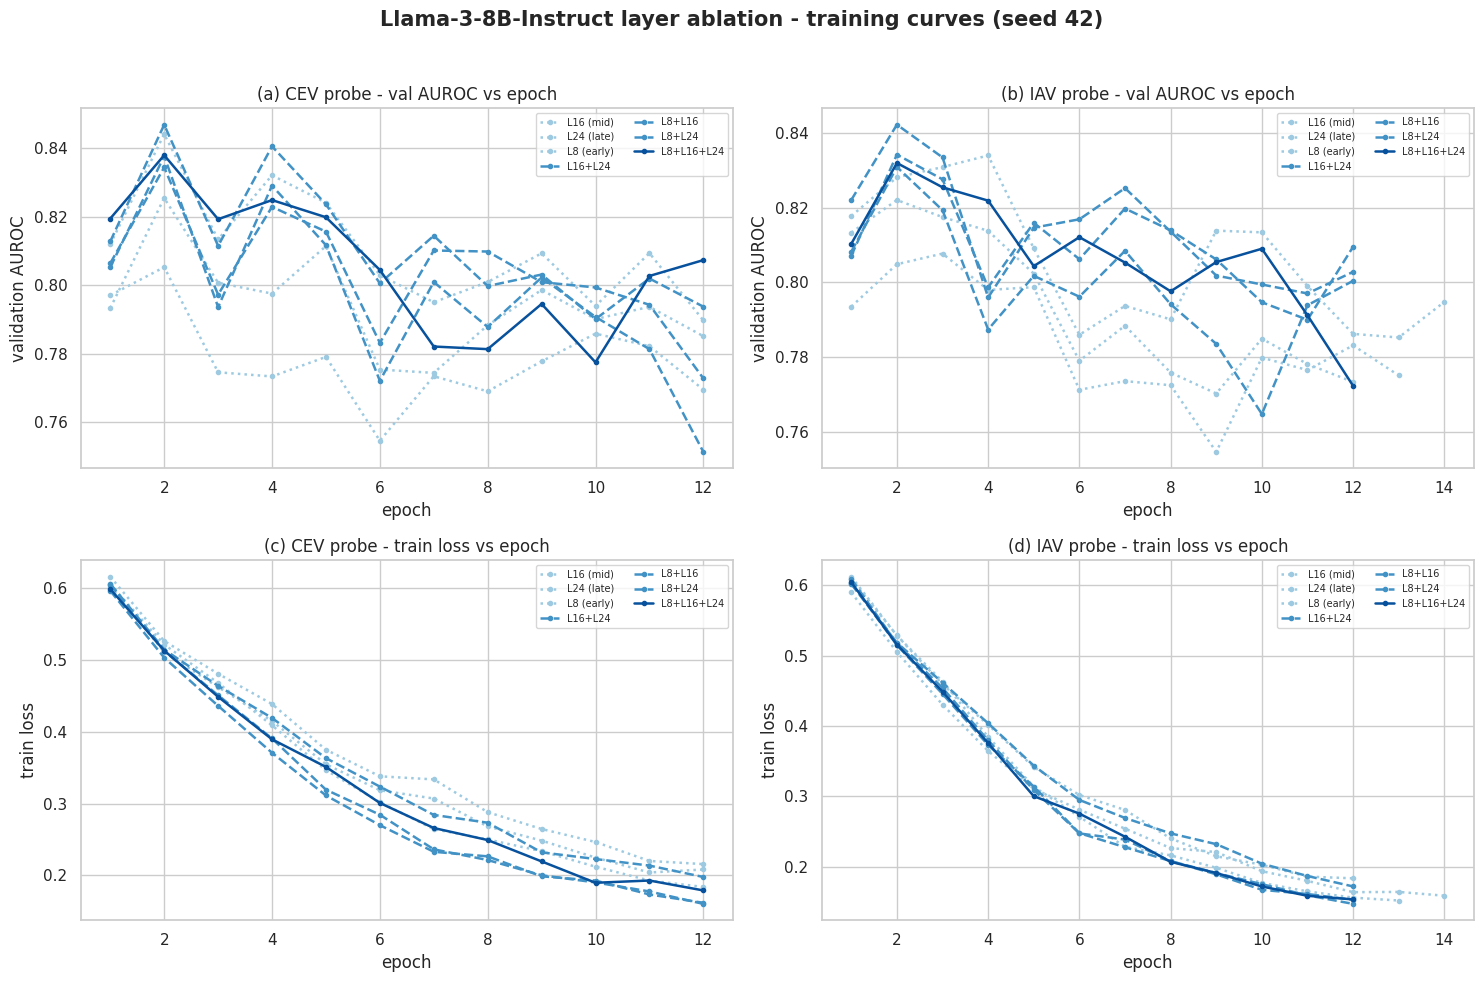

Saved -> /content/drive/MyDrive/llama_rag_hallucination/outputs/layerwise_ablation/layerwise_ablation_llama-3-8b-instruct_training_curves.png
Reading the curves: validation AUROC usually peaks within the first ~1-2 epochs then drifts down as the small probe head overfits; early stopping restores the best checkpoint, so the reported AUROC corresponds to that early peak.


In [11]:
# ==================================================================
# (a) Training curves: validation AUROC & train loss vs epoch
#     One line per configuration, captured on the first seed (SEEDS[0]).
# ==================================================================
import os as _os
# Persist to Google Drive (config.output_dir) so files survive runtime resets;
# fall back to a local folder only if Drive is unavailable.
_out_dir = _os.path.join(getattr(config, "output_dir", "."), "layerwise_ablation")
try:
    _os.makedirs(_out_dir, exist_ok=True)
except Exception:
    _out_dir = "qwen_outputs"; _os.makedirs(_out_dir, exist_ok=True)
print(f"[output dir] {_os.path.abspath(_out_dir)}")

_depth_color = {1: "#9ecae1", 2: "#4292c6", 3: "#08519c"}
_depth_ls = {1: ":", 2: "--", 3: "-"}
_names = sorted(training_curves.keys(),
                key=lambda n: (training_curves[n]["depth"], n))


def _plot_curve(ax, probe_key, metric, ylabel, title):
    for n in _names:
        h = training_curves[n][probe_key]
        if not h:
            continue
        ep = [d["epoch"] for d in h]
        yv = [d[metric] for d in h]
        d = training_curves[n]["depth"]
        ax.plot(ep, yv, _depth_ls[d], color=_depth_color[d], lw=1.8,
                marker="o", ms=3, label=n)
    ax.set_xlabel("epoch"); ax.set_ylabel(ylabel); ax.set_title(title)
    ax.legend(fontsize=7, ncol=2)


fig, axes = plt.subplots(2, 2, figsize=(15, 10))
_plot_curve(axes[0, 0], "cev", "auroc", "validation AUROC", "(a) CEV probe - val AUROC vs epoch")
_plot_curve(axes[0, 1], "iav", "auroc", "validation AUROC", "(b) IAV probe - val AUROC vs epoch")
_plot_curve(axes[1, 0], "cev", "train_loss", "train loss", "(c) CEV probe - train loss vs epoch")
_plot_curve(axes[1, 1], "iav", "train_loss", "train loss", "(d) IAV probe - train loss vs epoch")

fig.suptitle(f"Llama-3-8B-Instruct layer ablation - training curves (seed {SEEDS[0]})",
             fontsize=15, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.96])
_p = _os.path.join(_out_dir, "layerwise_ablation_llama-3-8b-instruct_training_curves.png")
fig.savefig(_p, dpi=150, bbox_inches="tight")
plt.show()
print("Saved ->", _os.path.abspath(_p))
print("Reading the curves: validation AUROC usually peaks within the first ~1-2 epochs "
      "then drifts down as the small probe head overfits; early stopping restores the "
      "best checkpoint, so the reported AUROC corresponds to that early peak.")


---
## 6. Visualisation - single vs double vs triple (with error bars)

Bars show the **mean over seeds**; whiskers show the **std over seeds**. Four panels:
**(a)** fused AUROC per configuration, **(b)** best AUROC at each depth, **(c)** AUROC
vs probe parameter count (cost/benefit), and **(d)** CEV vs IAV vs fused per
configuration. The printout flags when depth differences are within ~2 sigma (i.e.
not statistically meaningful at the current sample size).


[output dir] /content/drive/MyDrive/llama_rag_hallucination/outputs/layerwise_ablation


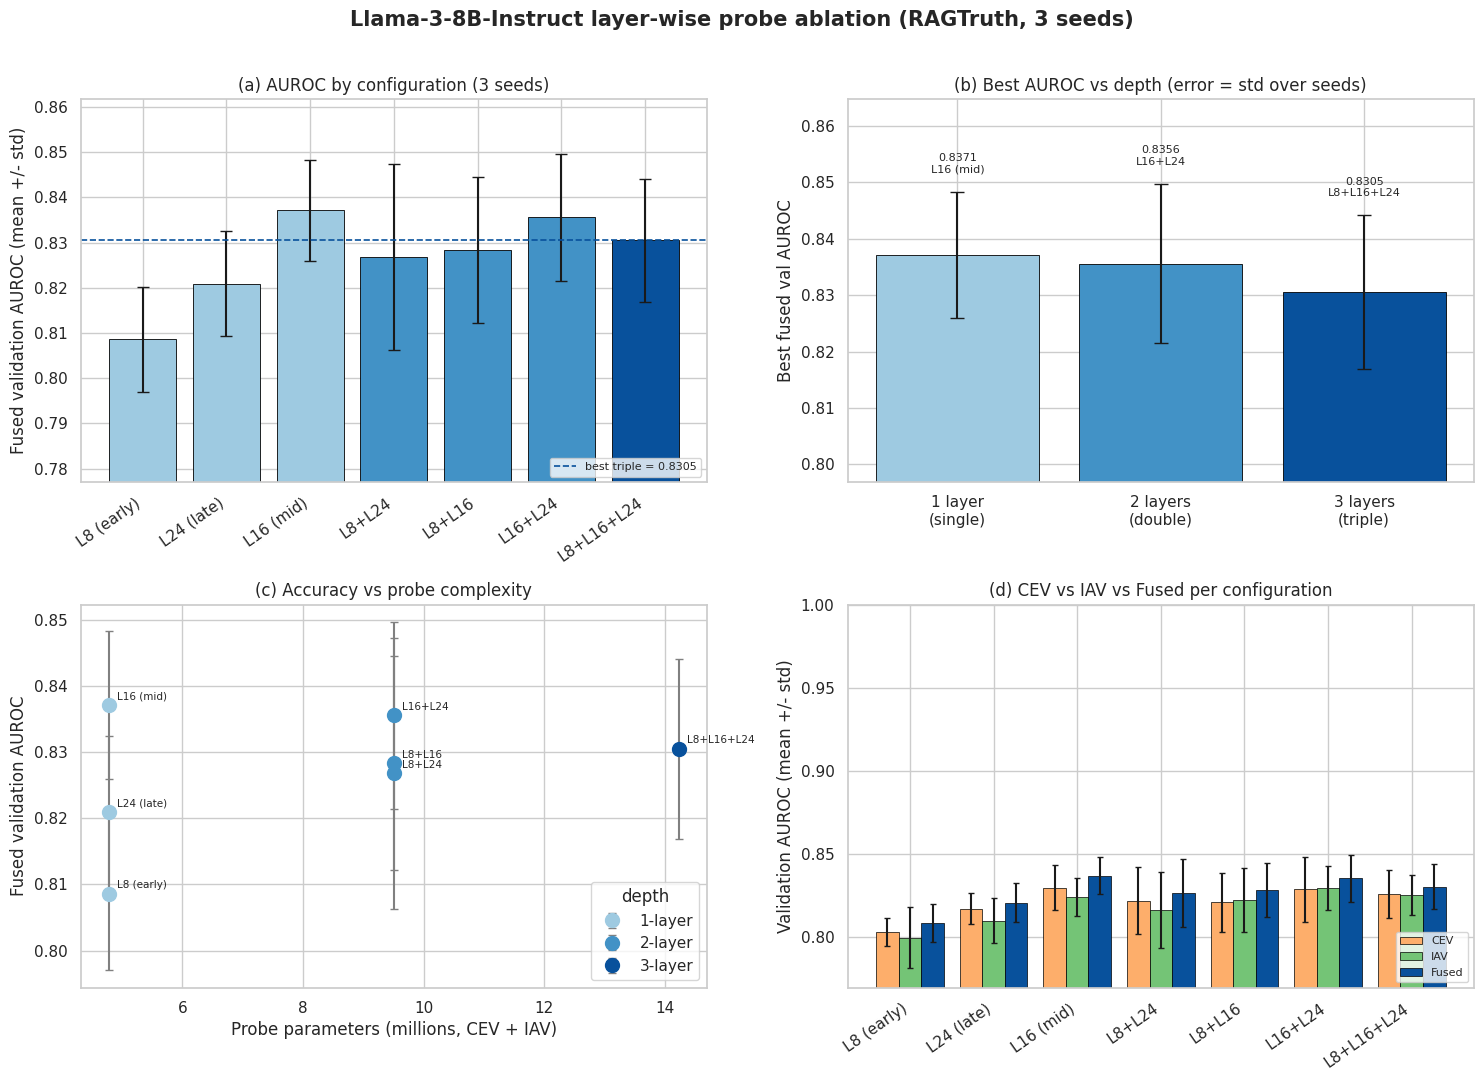

Saved figure -> /content/drive/MyDrive/llama_rag_hallucination/outputs/layerwise_ablation/layerwise_ablation_llama-3-8b-instruct.png

--- Marginal value of depth (best mean per depth) ---
  single -> double : -0.0016 AUROC
  double -> triple : -0.0051 AUROC
  typical per-seed std ~ 0.0141  ->  differences below ~0.0282 (2 sigma) are NOT statistically meaningful at this sample size.

  Triple vs best single (L16 (mid)): AUROC -0.0066, Acc -0.0179, F1 -0.0237  at 2.97x params.
  -> Triple tends to win on Acc/F1 (operating-point metrics); on AUROC it is typically within noise of the best single/double. Read the error bars before claiming a winner.


In [12]:
# ==================================================================
# (b) Visualization with error bars: single vs double vs triple
#     Bars = mean over seeds; error bars = std over seeds.
# ==================================================================
import os as _os
# Persist to Google Drive (config.output_dir) so files survive runtime resets;
# fall back to a local folder only if Drive is unavailable.
_out_dir = _os.path.join(getattr(config, "output_dir", "."), "layerwise_ablation")
try:
    _os.makedirs(_out_dir, exist_ok=True)
except Exception:
    _out_dir = "qwen_outputs"; _os.makedirs(_out_dir, exist_ok=True)
print(f"[output dir] {_os.path.abspath(_out_dir)}")

df = abl_df.copy()
depth_color = {1: "#9ecae1", 2: "#4292c6", 3: "#08519c"}
colors = [depth_color[d] for d in df["depth"]]
N_SEEDS_USED = int(seed_df["seed"].nunique())

best_triple = df[df.depth == 3]["fused_auroc_mean"].max()
best_single = df[df.depth == 1]["fused_auroc_mean"].max()
best_double = df[df.depth == 2]["fused_auroc_mean"].max()

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# (a) Fused AUROC per configuration, with std error bars --------------------
ax = axes[0, 0]
ax.bar(df["config"], df["fused_auroc_mean"], yerr=df["fused_auroc_std"], capsize=4,
       color=colors, edgecolor="black", linewidth=0.6)
ax.axhline(best_triple, ls="--", color="#08519c", lw=1.2, label=f"best triple = {best_triple:.4f}")
_lo = (df["fused_auroc_mean"] - df["fused_auroc_std"]).min()
_hi = (df["fused_auroc_mean"] + df["fused_auroc_std"]).max()
ax.set_ylim(max(0.5, _lo - 0.02), _hi + 0.012)
ax.set_ylabel("Fused validation AUROC (mean +/- std)")
ax.set_title(f"(a) AUROC by configuration ({N_SEEDS_USED} seeds)")
ax.set_xticklabels(df["config"], rotation=35, ha="right")
ax.legend(loc="lower right", fontsize=8)

# (b) Best AUROC by depth, error bars = std of that best config -------------
ax = axes[0, 1]
_rows = []
for d in (1, 2, 3):
    sub = df[df.depth == d]
    r = sub.loc[sub["fused_auroc_mean"].idxmax()]
    _rows.append((d, r["fused_auroc_mean"], r["fused_auroc_std"], r["config"]))
_mu = [r[1] for r in _rows]; _sd = [r[2] for r in _rows]
ax.bar(["1 layer\n(single)", "2 layers\n(double)", "3 layers\n(triple)"], _mu, yerr=_sd,
       capsize=5, color=[depth_color[d] for d in (1, 2, 3)], edgecolor="black", linewidth=0.6)
ax.set_ylim(max(0.5, min(m - s for m, s in zip(_mu, _sd)) - 0.02),
            max(m + s for m, s in zip(_mu, _sd)) + 0.015)
ax.set_ylabel("Best fused val AUROC")
ax.set_title("(b) Best AUROC vs depth (error = std over seeds)")
for bi, (m, s, c) in enumerate(zip(_mu, _sd, [r[3] for r in _rows])):
    ax.text(bi, m + s + 0.003, f"{m:.4f}\n{c}", ha="center", va="bottom", fontsize=8)

# (c) AUROC vs parameter count, with error bars -----------------------------
ax = axes[1, 0]
for d in (1, 2, 3):
    sub = df[df.depth == d]
    ax.errorbar(sub["total_params"] / 1e6, sub["fused_auroc_mean"], yerr=sub["fused_auroc_std"],
                fmt="o", ms=10, color=depth_color[d], ecolor="gray", capsize=3,
                label=f"{d}-layer", zorder=3)
for _, r in df.iterrows():
    ax.annotate(r["config"], (r["total_params"] / 1e6, r["fused_auroc_mean"]),
                textcoords="offset points", xytext=(6, 4), fontsize=7.5)
ax.set_xlabel("Probe parameters (millions, CEV + IAV)")
ax.set_ylabel("Fused validation AUROC")
ax.set_title("(c) Accuracy vs probe complexity")
ax.legend(title="depth")

# (d) Grouped CEV / IAV / Fused mean per configuration, with error bars ------
ax = axes[1, 1]
x = np.arange(len(df)); w = 0.27
ax.bar(x - w, df["cev_auroc_mean"], w, yerr=df["cev_auroc_std"], capsize=2,
       label="CEV", color="#fdae6b", edgecolor="black", linewidth=0.5)
ax.bar(x, df["iav_auroc_mean"], w, yerr=df["iav_auroc_std"], capsize=2,
       label="IAV", color="#74c476", edgecolor="black", linewidth=0.5)
ax.bar(x + w, df["fused_auroc_mean"], w, yerr=df["fused_auroc_std"], capsize=2,
       label="Fused", color="#08519c", edgecolor="black", linewidth=0.5)
ax.set_xticks(x); ax.set_xticklabels(df["config"], rotation=35, ha="right")
ax.set_ylim(max(0.5, df[["cev_auroc_mean", "iav_auroc_mean", "fused_auroc_mean"]].min().min() - 0.03), 1.0)
ax.set_ylabel("Validation AUROC (mean +/- std)")
ax.set_title("(d) CEV vs IAV vs Fused per configuration")
ax.legend(loc="lower right", fontsize=8)

fig.suptitle(f"Llama-3-8B-Instruct layer-wise probe ablation (RAGTruth, {N_SEEDS_USED} seeds)",
             fontsize=15, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.97])
_fig = _os.path.join(_out_dir, "layerwise_ablation_llama-3-8b-instruct.png")
fig.savefig(_fig, dpi=150, bbox_inches="tight")
plt.show()
print("Saved figure ->", _os.path.abspath(_fig))

# ---- Significance-aware takeaways ----
print("\n--- Marginal value of depth (best mean per depth) ---")
print(f"  single -> double : {best_double - best_single:+.4f} AUROC")
print(f"  double -> triple : {best_triple - best_double:+.4f} AUROC")
_pool_std = df["fused_auroc_std"].replace(0, np.nan).mean()
if not np.isnan(_pool_std):
    print(f"  typical per-seed std ~ {_pool_std:.4f}  ->  differences below ~{2*_pool_std:.4f} "
          f"(2 sigma) are NOT statistically meaningful at this sample size.")
_tri = df[df.depth == 3].iloc[0]
_bs = df[df.depth == 1].sort_values("fused_auroc_mean").iloc[-1]
print(f"\n  Triple vs best single ({_bs['config']}): "
      f"AUROC {_tri['fused_auroc_mean']-_bs['fused_auroc_mean']:+.4f}, "
      f"Acc {_tri['fused_acc_mean']-_bs['fused_acc_mean']:+.4f}, "
      f"F1 {_tri['fused_f1_mean']-_bs['fused_f1_mean']:+.4f}  "
      f"at {_tri['total_params']/_bs['total_params']:.2f}x params.")
print("  -> Triple tends to win on Acc/F1 (operating-point metrics); on AUROC it is "
      "typically within noise of the best single/double. Read the error bars before "
      "claiming a winner.")


---
## 7. Summary - is the 3-layer concat justified?

### Recap of the configurations
| Depth | Configs | Count | Probe params | Rel. cost |
|-------|---------|:-----:|:------------:|:---------:|
| Single | `{8}`,`{16}`,`{24}` | 3 | 4,786,948 | 1x |
| Double | `{8,16}`,`{8,24}`,`{16,24}` | 3 | 9,505,540 | ~2x |
| **Triple** | **`{8,16,24}`** | 1 | 14,224,132 | ~3x |

### What the 3-seed results actually say (RAGTruth, 4000 rows, mean +/- std)
Metrics are reported as **AUROC / Accuracy / F1** at a fixed 0.5 threshold.

| Config | AUROC | Accuracy | F1 |
|--------|:-----:|:--------:|:--:|
| early `L8` | .8086 | .7275 | .6868 |
| **mid `L16`** | **.8371 +/- .0112** | **.7596 +/- .0071** | **.7286 +/- .0074** |
| late `L24` | .8209 | .7417 | .7065 |
| `L8+L16` | .8284 | .7429 | .7027 |
| `L8+L24` | .8268 | .7504 | .7129 |
| `L16+L24` | .8356 | .7542 | .7172 |
| triple `L8+L16+L24` | .8305 | .7417 | .7049 |

- **Mid `L16` sweeps every metric** - best AUROC, Accuracy *and* F1
  (.8371 / .7596 / .7286) - and also has the **lowest seed-to-seed variance**.
- No double or triple beats the single mid layer on any metric. The closest is the
  2-layer `L16+L24` (.8356 / .7542 / .7172), still behind mid on all three.
- **The triple never wins** (.8305 / .7417 / .7049) and costs **~3x** the parameters
  (14.22M vs 4.79M); its mean AUROC is *below* the single mid layer.
- Early (`L8`) is the weakest single layer, consistent with the signal accumulating
  with depth.

### Verdict
For Llama-3-8B-Instruct the conclusion is unambiguous: the **single mid layer (`L16`)**
is the best probe on **all three metrics** while using **~1/3 the parameters** of the
triple and showing the **lowest variance**. The **3-layer concat is not justified**.
This is the cleanest instance of the cross-model finding (see
`compare-models__Layer_wise_probe_ablation.ipynb`): the **single mid layer (N/2)** is
the best system-agnostic choice.

### Runtime / resource notes
- Host RAM is bounded (~0.9 GB cached features); the batched extraction + pre-allocated
  buffers avoid the host-RAM OOM. Raise `ABL_BATCH_SIZE` (32-64 on an 80 GB A100) to use
  more GPU and extract faster.
- `N_SEEDS` controls the error-bar strength (3 here); `ABLATION_N_SAMPLES` controls the
  RAGTruth subset (4000 used).
- Saved artifacts: `layerwise_ablation_llama-3-8b-instruct.{csv,png}`, `..._per_seed.csv`,
  `..._training_curves.png` under `config.output_dir/layerwise_ablation/`.